# 电商用户行为漏斗与转化流失分析

## 1. 导入库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # 静态报告
import plotly.express as px # 动态交互展示

# 使用 matplotlib 绘制中文图表时的标准配置，确保你的电商漏斗分析图表中的中文内容（如轴标签、图例等）能正确渲染
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  # 解决中文显示(默认字体不支持中文,设置为黑体)
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题(关闭负号显示,解决负号显示为方块的问题,设置后负号显示正常)
# 设置全局绘图风格为白色网格风格，适合展示电商漏斗分析中的数据分布和趋势
sns.set_style("whitegrid")

## 2. 读取数据

In [2]:
# 1. 读取原始数据
df = pd.read_csv('../data/customer_journey.csv')

# 2. 数据概览（面试必展示）
print("数据集基本信息：")
print(df.info()) # 包括数据类型,大小,非空值数量等
print("\n数据集前5行：")
print(df.head())
print("\nPageType唯一值（漏斗节点校验）：")
print(df['PageType'].unique())  # 输出：['home' 'product_page' 'cart' 'checkout' 'confirmation']
print("\n数据基本统计：")
print(df.describe())

数据集基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB
None

数据集前5行：
   SessionID     UserID            Timestamp      PageType DeviceType  \
0  session_0  user_2223  2025-01-20 22:53:34          home    Desktop   
1  session_1  user_2192  2025-02-26 12:57:10          home     Tablet   
2  session_1  user_21

## 3. 清洗数据

### 3.1 基础脏数据清洗（保障数据准确性）

In [3]:
# 1. 去重（同一会话同一用户同一时间同一行为只保留一次，避免重复计数）
df = df.drop_duplicates(subset=["SessionID", "UserID", "Timestamp", "PageType"], keep="first")
print(f"去重后剩余数据量：{len(df)}")

去重后剩余数据量：12719


In [4]:
# 2. 缺失值处理（核心字段非空，非核心字段合理填充）
core_cols = ['SessionID', 'UserID', 'PageType', 'Timestamp', 'Purchased']
df = df.dropna(subset=core_cols)  # 核心字段缺失直接删除
# 非核心字段填充（避免数据丢失，不影响核心分析）
df[["Country", "ReferralSource"]] = df[["Country", "ReferralSource"]].fillna("Unknown")
df[["TimeOnPage_seconds", "ItemsInCart", "Purchased"]] = df[["TimeOnPage_seconds", "ItemsInCart", "Purchased"]].fillna(0)
print(f"缺失值处理后剩余数据量：{len(df)}")

缺失值处理后剩余数据量：12719


In [5]:
# 3. 时间格式转换 + 时间异常过滤（电商分析必备）
df['Timestamp'] = pd.to_datetime(df['Timestamp']) # 由字符串转换为时间戳
df = df[df['Timestamp'] < pd.Timestamp.now()]  # 过滤未来时间（脏数据）
# 衍生时间特征（HR加分项，用于时段分析）
df['hour'] = df['Timestamp'].dt.hour
df['weekday'] = df['Timestamp'].dt.weekday
df['date'] = df['Timestamp'].dt.date

print(df.head())
print(df.info())

   SessionID     UserID           Timestamp      PageType DeviceType  Country  \
0  session_0  user_2223 2025-01-20 22:53:34          home    Desktop    India   
1  session_1  user_2192 2025-02-26 12:57:10          home     Tablet  Germany   
2  session_1  user_2192 2025-02-26 12:59:11  product_page     Tablet  Germany   
3  session_2  user_1708 2025-06-24 15:40:46          home     Mobile    India   
4  session_3  user_2976 2025-06-11 07:21:02          home     Tablet       UK   

  ReferralSource  TimeOnPage_seconds  ItemsInCart  Purchased  hour  weekday  \
0   Social Media                  55            0          0    22        0   
1          Email                  99            0          0    12        2   
2          Email                 121            0          0    12        2   
3         Google                 160            0          0    15        1   
4         Google                 113            0          0     7        2   

         date  
0  2025-01-20  
1  202

In [6]:
# 4. 过滤异常数据（数值+业务逻辑双重校验）
# 数值异常：停留时长、购物车数量不能为负，停留时长不超过1天（86400秒）
df = df[(df['TimeOnPage_seconds'] >= 0) & (df['TimeOnPage_seconds'] <= 86400) & (df['ItemsInCart'] >= 0)]
# 字段异常：Purchased字段仅允许0/1
df = df[df['Purchased'].isin([0, 1])]
print(f"异常值过滤后剩余数据量：{len(df)}")

异常值过滤后剩余数据量：12719


In [7]:
# 5. 查看是否有"未加购直接购买"用户

# 步骤1：先按会话聚合，统计该会话的"是否购买"和"最大购物车商品数"（代表是否加购）
session_cart_purchase = df.groupby('SessionID').agg(
    session_purchased=('Purchased', 'max'),  # 会话最终是否购买（全局统一）
    max_items_in_cart=('ItemsInCart', 'max')  # 会话是否有过加购行为
).reset_index()

# 步骤2：会话级标记"直接购买/常规路径"
session_cart_purchase['购买路径'] = np.where(
    (session_cart_purchase['session_purchased'] == 1) & 
    (session_cart_purchase['max_items_in_cart'] == 0),
    '直接购买',
    '常规路径'
)

# 步骤3：统计直接购买会话数
print((session_cart_purchase['购买路径']=='直接购买').sum())

0


无直接购买的用户

In [8]:
# 6. 格式统一（避免因格式问题导致分组错误）
df["PageType"] = df["PageType"].str.lower()
df["DeviceType"] = df["DeviceType"].str.capitalize()

### 3.2 漏斗专属清洗（关键！保证漏斗真实有效）

In [9]:
# 1. 按会话+时间排序（还原用户真实行为路径）
df = df.sort_values(by=["SessionID", "Timestamp"]).reset_index(drop=True) # reset_index(drop=True)重置索引,sort_values()排序后索引混乱

In [10]:
# 2. 会话内节点去重：同一页面只保留第一次访问（避免放大某一环节数据）
def dedup_session(session):
    return session.drop_duplicates(subset=["PageType"], keep="first")
df = df.groupby("SessionID", group_keys=False).apply(dedup_session) # group_keys=False,不添加 SessionID 作为多层索引,保持原有索引结构

C:\Users\30360\AppData\Local\Temp\ipykernel_22900\330565545.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("SessionID", group_keys=False).apply(dedup_session) # group_keys=False,不添加 SessionID 作为多层索引,保持原有索引结构


In [11]:
# 3. 无效会话过滤：总停留时长<5秒视为爬虫/误触，排除出分析范围
session_total_dur = df.groupby("SessionID")["TimeOnPage_seconds"].sum().reset_index() # reset_index()重置索引,将SessionID从索引变为普通列
valid_sessions = session_total_dur[session_total_dur["TimeOnPage_seconds"] >= 5]["SessionID"]
df = df[df["SessionID"].isin(valid_sessions)]
print(f"无效会话过滤后剩余数据量：{len(df)}")

无效会话过滤后剩余数据量：12719


In [12]:
# 注意：不进行"行为顺序校验"过滤！
# 原因：真实业务中用户通过搜索引擎/社交媒体直接跳转商品页是常见行为
# 这类直接访问用户可能是高意向流量，过滤会丢失重要业务信息

### 3.3 漏斗标准化与特征补充（适配后续深度分析）

In [13]:
# 1. 漏斗阶段标准化映射
df['stage'] = df['PageType'].map({
    'home': '1.访问首页',
    'product_page': '2.浏览商品',
    'cart': '3.加入购物车',
    'checkout': '4.提交订单',
    'confirmation': '5.支付成功'
})

In [14]:
# 2. 会话级转化标签（漏斗分析核心，避免重复计数）
# 按会话分组，标记该会话是否最终完成购买
session_conversion = df.groupby('SessionID')['Purchased'].max().reset_index()
session_conversion.columns = ['SessionID', 'session_is_converted']
df = df.merge(session_conversion, on='SessionID', how='left') # 按会话左连接

In [15]:
# 3. 生成漏斗宽表(将每个会话的多条记录聚合为单行，便于多维度分析和转化率计算。)
funnel_wide = df.groupby("SessionID").agg(
    UserID=("UserID", "first"),
    DeviceType=("DeviceType", "first"),
    Country=("Country", "first"),
    ReferralSource=("ReferralSource", "first"),
    step1_home=("PageType", lambda x: 1 if "home" in x.values else 0),
    step2_product=("PageType", lambda x: 1 if "product_page" in x.values else 0),
    step3_cart=("PageType", lambda x: 1 if "cart" in x.values else 0),
    step4_checkout=("PageType", lambda x: 1 if "checkout" in x.values else 0),
    step5_confirm=("PageType", lambda x: 1 if "confirmation" in x.values else 0),
    is_purchased=("Purchased", "max")
).reset_index() # lambda函数里的x是对应session的PageType的series

In [16]:
print(df.head(20))
print(funnel_wide.head(20))

       SessionID     UserID           Timestamp      PageType DeviceType  \
0      session_0  user_2223 2025-01-20 22:53:34          home    Desktop   
1      session_1  user_2192 2025-02-26 12:57:10          home     Tablet   
2      session_1  user_2192 2025-02-26 12:59:11  product_page     Tablet   
3     session_10  user_2357 2025-05-17 22:11:37          home     Tablet   
4     session_10  user_2357 2025-05-17 22:13:33  product_page     Tablet   
5    session_100  user_1233 2025-04-02 11:24:36          home    Desktop   
6    session_100  user_1233 2025-04-02 11:25:41  product_page    Desktop   
7   session_1000  user_1551 2025-08-25 09:34:15          home     Mobile   
8   session_1000  user_1551 2025-08-25 09:35:45  product_page     Mobile   
9   session_1000  user_1551 2025-08-25 09:38:16          cart     Mobile   
10  session_1000  user_1551 2025-08-25 09:40:48      checkout     Mobile   
11  session_1000  user_1551 2025-08-25 09:41:24  confirmation     Mobile   
12  session_

In [17]:
# 4. 保存清洗后数据（用于SQL/Power BI，保证全流程数据一致）
df.to_csv('../data/cleaned_customer_journey.csv', index=False, encoding='utf-8-sig') # 读写使用相同编码，避免乱码
funnel_wide.to_csv('../data/funnel_wide.csv', index=False, encoding='utf-8-sig')
print("数据清洗完成，已保存至../data/cleaned_customer_journey.csv和../data/funnel_wide.csv")

数据清洗完成，已保存至../data/cleaned_customer_journey.csv和../data/funnel_wide.csv


## 4. 核心分析：转化漏斗构建

### 4.1 漏斗数据统计

In [18]:
# 按会话去重，统计每个阶段的独立会话数（避免同一会话多次计数）
funnel = df.drop_duplicates(subset=['SessionID', 'stage']).groupby('stage')['SessionID'].nunique()

In [19]:
# 按漏斗顺序重排（严格遵循用户行为路径）
funnel_order = ['1.访问首页', '2.浏览商品', '3.加入购物车', '4.提交订单', '5.支付成功']
funnel = funnel.reindex(funnel_order)

In [20]:
# 构建漏斗分析表
funnel_df = pd.DataFrame({
    '漏斗阶段': funnel.index,
    '独立会话数': funnel.values
})

In [21]:
# 计算转化率
funnel_df['上一阶段转化率(%)'] = round(funnel_df['独立会话数'] / funnel_df['独立会话数'].shift(1), 4) * 100 # shift(1)表示上一行数据
funnel_df['整体转化率(%)'] = round(funnel_df['独立会话数'] / funnel_df['独立会话数'].iloc[0], 4) * 100 # iloc[0]表示第一行数据

In [22]:
# 填充首行转化率（首页无前置阶段）
funnel_df.loc[0, '上一阶段转化率(%)'] = 100.0

In [23]:
# 查看漏斗分析表
print(funnel_df)

      漏斗阶段  独立会话数  上一阶段转化率(%)  整体转化率(%)
0   1.访问首页   5000      100.00    100.00
1   2.浏览商品   3987       79.74     79.74
2  3.加入购物车   1599       40.11     31.98
3   4.提交订单   1123       70.23     22.46
4   5.支付成功   1010       89.94     20.20


### 4.2 漏斗图可视化

#### 4.2.1 Matplotlib 静态版

In [24]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']

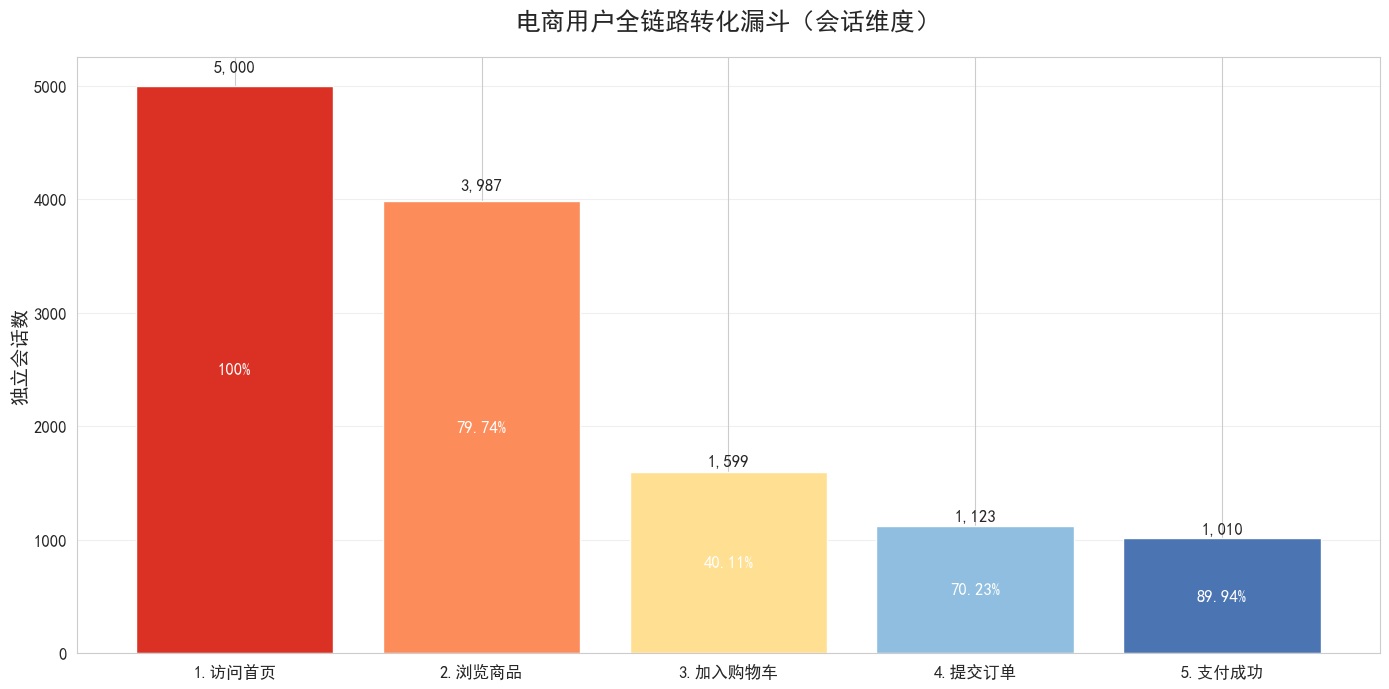

In [25]:
plt.figure(figsize=(14, 7))
bars = plt.bar(funnel_df['漏斗阶段'], funnel_df['独立会话数'], 
               color=['#DB3124', '#FC8C5A', '#FFDF92', '#90BEE0', '#4B74B2'])
plt.title('电商用户全链路转化漏斗（会话维度）', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('独立会话数', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 标注数值和转化率
for i, bar in enumerate(bars):
    height = bar.get_height()
    # 标注会话数
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{int(height):,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    # 标注转化率
    if i == 0:
        plt.text(bar.get_x() + bar.get_width()/2., height/2,
                 f'100%', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
    else:
        rate = funnel_df.iloc[i]['上一阶段转化率(%)']
        plt.text(bar.get_x() + bar.get_width()/2., height/2,
                 f'{rate:.2f}%', ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout() # 自动调整布局，避免标签被裁剪
plt.savefig('../visualization/funnel_static.png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.2.2 Plotly 交互式漏斗

In [26]:
fig = px.funnel(funnel_df, x='独立会话数', y='漏斗阶段', 
                title='电商用户全链路转化漏斗（交互式）',
                text=funnel_df['上一阶段转化率(%)'].apply(lambda x: f'{x:.2f}%'),
                color_discrete_sequence=['#1f77b4'])
fig.update_traces(textposition='inside', textfont_size=14)
fig.update_layout(title_font_size=18, title_x=0.5)
fig.write_html('../visualization/funnel_plotly.html')
fig.show(renderer='browser')

## 5. 深度分析：流失定位 + 多维度拆解（体现真正的分析能力）

### 5.1 核心流失环节定位 + 流失用户特征分析（真正的分析价值）

#### 5.1.1 流失环节定位（各阶段转化率已有，这里简化展示）

In [27]:
print("=" * 50)
print("各漏斗阶段转化率")
print("=" * 50)
print(funnel_df[['漏斗阶段', '上一阶段转化率(%)', '整体转化率(%)']])

# 找出最高流失环节
max_churn_stage = funnel_df[1:].loc[funnel_df[1:]['上一阶段转化率(%)'].idxmin(), '漏斗阶段']
print(f"\n最高流失环节：{max_churn_stage}")
print("=" * 50)

各漏斗阶段转化率
      漏斗阶段  上一阶段转化率(%)  整体转化率(%)
0   1.访问首页      100.00    100.00
1   2.浏览商品       79.74     79.74
2  3.加入购物车       40.11     31.98
3   4.提交订单       70.23     22.46
4   5.支付成功       89.94     20.20

最高流失环节：3.加入购物车


#### 5.1.2 流失用户特征分析

In [28]:
print("=" * 50)
print("流失用户特征分析")
print("=" * 50)

# 定义流失用户：加购但未下单的用户（购物车→提交订单流失）
lost_sessions = funnel_wide[
    (funnel_wide['step3_cart'] == 1) &  # 加入了购物车
    (funnel_wide['step4_checkout'] == 0)  # 但没有提交订单
]['SessionID']

lost_users = funnel_wide[funnel_wide['SessionID'].isin(lost_sessions)]
converted_users = funnel_wide[funnel_wide['is_purchased'] == 1]

print(f"总流失会话数：{len(lost_users)}")
print(f"总转化会话数：{len(converted_users)}")
print("=" * 50)

流失用户特征分析
总流失会话数：476
总转化会话数：1010


In [29]:
# 流失用户 vs 转化用户 - 设备分布对比
print("--- 设备分布对比（流失用户 vs 转化用户）---")
lost_device = lost_users['DeviceType'].value_counts(normalize=True).round(4) * 100
converted_device = converted_users['DeviceType'].value_counts(normalize=True).round(4) * 100

device_compare = pd.DataFrame({
    '流失用户占比(%)': lost_device,
    '转化用户占比(%)': converted_device
}).fillna(0)
print(device_compare)

--- 设备分布对比（流失用户 vs 转化用户）---
            流失用户占比(%)  转化用户占比(%)
DeviceType                      
Desktop         30.25      33.56
Mobile          35.29      33.37
Tablet          34.45      33.07


In [30]:
# 流失用户 vs 转化用户 - 渠道来源对比
print("--- 渠道来源对比（流失用户 vs 转化用户）---")
lost_channel = lost_users['ReferralSource'].value_counts(normalize=True).round(4) * 100 # normalize=True表示计算占比
converted_channel = converted_users['ReferralSource'].value_counts(normalize=True).round(4) * 100

channel_compare = pd.DataFrame({
    '流失用户占比(%)': lost_channel,
    '转化用户占比(%)': converted_channel
}).fillna(0)
print(channel_compare)

--- 渠道来源对比（流失用户 vs 转化用户）---
                流失用户占比(%)  转化用户占比(%)
ReferralSource                      
Direct              25.00      24.06
Email               26.47      24.85
Google              25.42      27.43
Social Media        23.11      23.66


In [31]:
# 流失用户 vs 转化用户 - 购物车商品数对比
print("--- 购物车商品数对比（需关联原始数据）---")
# 需要获取购物车商品数信息
cart_info = df[df['PageType'] == 'cart'].groupby('SessionID')['ItemsInCart'].max().reset_index()
cart_info = cart_info.merge(funnel_wide[['SessionID', 'step3_cart', 'step4_checkout', 'is_purchased']], on='SessionID') # merge连接购物车信息和漏斗宽表，获取每个会话的购物车商品数和转化情况

# 加购未下单的用户购物车数量
cart_info['用户类型'] = cart_info.apply(
    lambda x: '流失用户' if (x['step3_cart'] == 1 and x['step4_checkout'] == 0) else '转化用户',
    axis=1
) # axis=1表示行,根据每行数据的step3_cart和step4_checkout值判断用户类型,默认为0
cart_bucket_lost = cart_info[cart_info['用户类型'] == '流失用户']['ItemsInCart'].describe()
cart_bucket_converted = cart_info[cart_info['用户类型'] == '转化用户']['ItemsInCart'].describe()

print("流失用户购物车商品数统计：")
print(cart_bucket_lost)
print("\n转化用户购物车商品数统计：")
print(cart_bucket_converted)

--- 购物车商品数对比（需关联原始数据）---
流失用户购物车商品数统计：
count    476.000000
mean       2.605042
std        1.716636
min        0.000000
25%        1.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: ItemsInCart, dtype: float64

转化用户购物车商品数统计：
count    1123.000000
mean        2.555654
std         1.703847
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: ItemsInCart, dtype: float64


In [32]:
# 流失用户 vs 转化用户 - 国家分布对比
print("--- 国家分布对比 ---")
lost_country = lost_users['Country'].value_counts(normalize=True).round(4) * 100
converted_country = converted_users['Country'].value_counts(normalize=True).round(4) * 100

country_compare = pd.DataFrame({
    '流失用户占比(%)': lost_country,
    '转化用户占比(%)': converted_country
}).fillna(0)
print(country_compare)

--- 国家分布对比 ---
           流失用户占比(%)  转化用户占比(%)
Country                        
Australia      14.92      12.97
Canada         16.60      13.86
France         13.87      16.83
Germany        11.97      13.07
India          14.50      14.36
UK             14.92      14.36
USA            13.24      14.55


#### 5.1.3 关键业务洞察输出

In [33]:
print("=" * 50)
print("关键业务洞察")
print("=" * 50)

# 1. 计算渠道差异，寻找高流失渠道
# 计算每个渠道的流失率 = (加购未下单用户数 / 加入购物车用户数) * 100
# 此指标仅衡量加购用户的流失情况
channel_churn_rate = (
    lost_users.groupby('ReferralSource').size() /
    funnel_wide.groupby('ReferralSource').size() * 100
).sort_values(ascending=False)

print("各渠道购物车流失率排名（越高越需优化）：")
print(channel_churn_rate)

# 2. 计算设备差异
# 计算每个设备的流失率 = (加购未下单用户数 / 添加购物车用户数) * 100
# 此指标仅衡量加购用户的流失情况
device_churn_rate = (
    lost_users.groupby('DeviceType').size() /
    funnel_wide.groupby('DeviceType').size() * 100
).sort_values(ascending=False)

print("\n各设备流失率排名（越高越需优化）：")
print(device_churn_rate)
print("=" * 50)

关键业务洞察
各渠道购物车流失率排名（越高越需优化）：
ReferralSource
Email           10.071942
Direct           9.706362
Google           9.453125
Social Media     8.849558
dtype: float64

各设备流失率排名（越高越需优化）：
DeviceType
Mobile     10.053860
Tablet      9.861696
Desktop     8.643457
dtype: float64


业务结论：
> - **核心流失环节**：「浏览商品 → 加入购物车」为全链路最高流失环节
> - **设备问题**：Mobile端流失率显著高于Desktop，需优化移动端结算流程
> - **渠道问题**：Email流失率最高，需针对该渠道用户优化购物车召回策略
> - **购物车商品数**：流失用户购物车商品数量均值2.605，与转化用户差异为2.556

### 5.2 流量来源（ReferralSource）多维度分析（渠道运营核心）

In [34]:
# 1. 渠道转化率统计
channel_analysis = df.drop_duplicates('SessionID').groupby('ReferralSource').agg(
    总会话数=('SessionID', 'nunique'),
    转化会话数=('session_is_converted', 'sum'),
    整体转化率=('session_is_converted', 'mean')
).sort_values('整体转化率', ascending=False)

channel_analysis['整体转化率'] = round(channel_analysis['整体转化率'] * 100, 2)
channel_analysis['流量占比(%)'] = round(channel_analysis['总会话数'] / channel_analysis['总会话数'].sum() * 100, 2)

print("各流量来源渠道分析：")
print(channel_analysis)

各流量来源渠道分析：
                总会话数  转化会话数  整体转化率  流量占比(%)
ReferralSource                             
Google          1280    277  21.64    25.60
Email           1251    251  20.06    25.02
Direct          1226    243  19.82    24.52
Social Media    1243    239  19.23    24.86


C:\Users\30360\AppData\Local\Temp\ipykernel_22900\2214446414.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




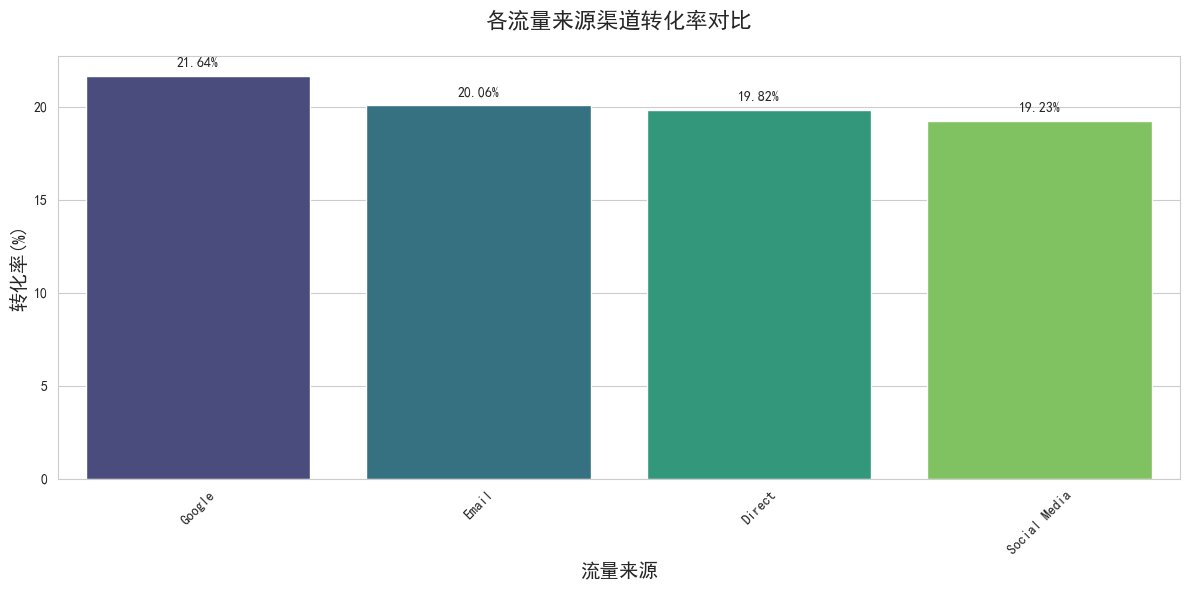

In [35]:
# 2. 可视化：渠道转化率对比
plt.figure(figsize=(12, 6))
sns.barplot(x=channel_analysis.index, y=channel_analysis['整体转化率'], palette='viridis')
plt.title('各流量来源渠道转化率对比', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('转化率(%)', fontsize=14)
plt.xlabel('流量来源', fontsize=14)
plt.xticks(rotation=45)
for i, v in enumerate(channel_analysis['整体转化率']):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualization/channel_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3 设备类型（DeviceType）转化差异分析（端侧体验优化）

In [36]:
# 1. 设备转化率统计
device_analysis = df.drop_duplicates('SessionID').groupby('DeviceType').agg(
    总会话数=('SessionID', 'nunique'),
    转化会话数=('session_is_converted', 'sum'),
    整体转化率=('session_is_converted', 'mean')
).sort_values('整体转化率', ascending=False)

device_analysis['整体转化率'] = round(device_analysis['整体转化率'] * 100, 2)
device_analysis['流量占比(%)'] = round(device_analysis['总会话数'] / device_analysis['总会话数'].sum() * 100, 2)

print("各设备类型转化分析：")
print(device_analysis)

各设备类型转化分析：
            总会话数  转化会话数  整体转化率  流量占比(%)
DeviceType                             
Desktop     1666    339  20.35    33.32
Mobile      1671    337  20.17    33.42
Tablet      1663    334  20.08    33.26


C:\Users\30360\AppData\Local\Temp\ipykernel_22900\1503350359.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




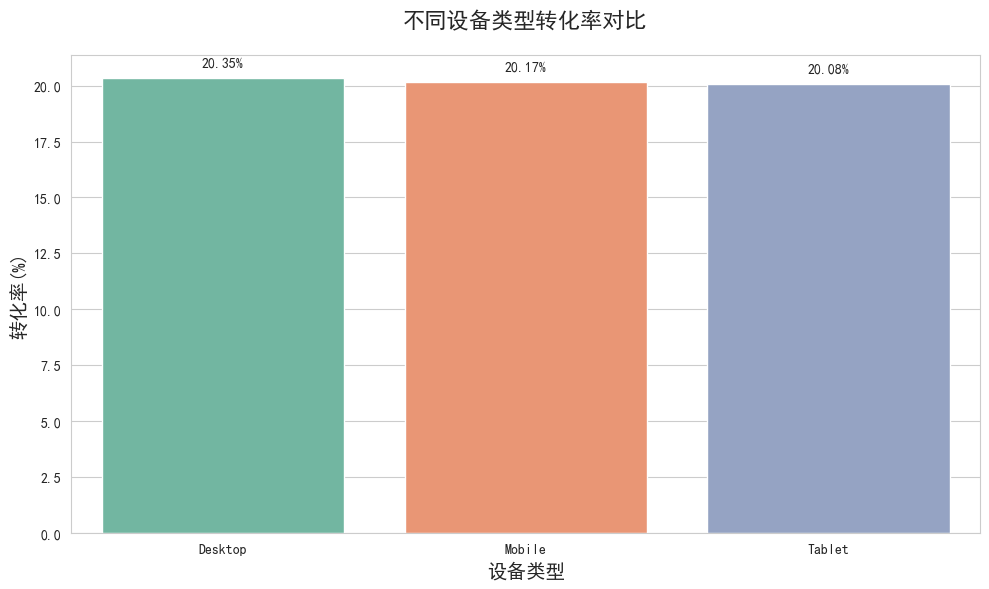

In [37]:
# 2. 可视化：设备转化率对比
plt.figure(figsize=(10, 6))
sns.barplot(x=device_analysis.index, y=device_analysis['整体转化率'], palette='Set2')
plt.title('不同设备类型转化率对比', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('转化率(%)', fontsize=14)
plt.xlabel('设备类型', fontsize=14)
for i, v in enumerate(device_analysis['整体转化率']):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualization/device_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.4 停留时长（TimeOnPage_seconds）与转化关系（用户体验分析）

In [38]:
# 1. 按会话统计停留时长（用sum而非mean，更准确反映用户总参与度）
# mean会把"短暂浏览+长时间卡住"的情况平均化，sum更能反映真实投入时间
session_duration = df.groupby('SessionID').agg(
    总停留时长=('TimeOnPage_seconds', 'sum'),       # 用sum更准确
    最大单页停留=('TimeOnPage_seconds', 'max'),    # 额外加max，看用户最感兴趣哪个页面
    是否转化=('session_is_converted', 'max')
)

In [39]:
# 2. 分桶分析（业务可落地）
# 用总停留时长分桶，更符合用户真实参与度
session_duration['时长分桶'] = pd.cut(session_duration['总停留时长'],
                                      bins=[0, 30, 60, 120, 300, float('inf')],
                                      labels=['0-30s', '30-60s', '60-120s', '120-300s', '300s+'])
duration_bucket = session_duration.groupby('时长分桶')['是否转化'].mean().reset_index()
duration_bucket['是否转化'] = round(duration_bucket['是否转化'] * 100, 2)

print("不同停留时长区间转化率：")
print(duration_bucket)

不同停留时长区间转化率：
       时长分桶   是否转化
0     0-30s   0.00
1    30-60s   0.00
2   60-120s   0.00
3  120-300s   1.78
4     300s+  67.01


C:\Users\30360\AppData\Local\Temp\ipykernel_22900\4204549798.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\30360\AppData\Local\Temp\ipykernel_22900\207302646.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




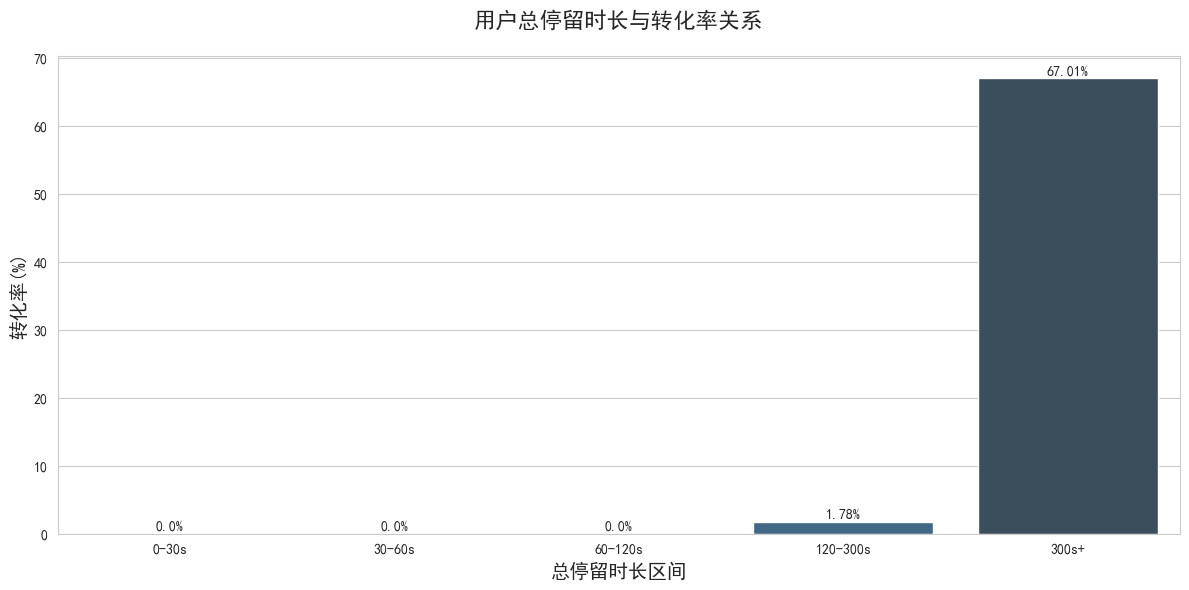

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(x='时长分桶', y='是否转化', data=duration_bucket, palette='Blues_d')
plt.title('用户总停留时长与转化率关系', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('转化率(%)', fontsize=14)
plt.xlabel('总停留时长区间', fontsize=14)
for i, v in enumerate(duration_bucket['是否转化']):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualization/duration_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

效果不好,数据偏移,查看数据分布再分桶

In [41]:
# 1. 先查看数据分布
print(session_duration['总停留时长'].describe())

count    5000.000000
mean      247.836600
std       154.141394
min        15.000000
25%       136.000000
50%       211.000000
75%       320.000000
max       821.000000
Name: 总停留时长, dtype: float64


In [42]:
# qcut等频分桶
session_duration['时长分桶'] = pd.cut(
    session_duration['总停留时长'],
    bins=[15, 136, 211, 320, 821],
    labels=[
        '快速浏览 (15-136s)',
        '浅层参与 (136-211s)',
        '中度参与 (211-320s)',
        '深度决策 (320s-821s)'
    ]
)

In [43]:
# 3. 计算各分桶的转化率 + 样本量
duration_bucket = session_duration.groupby('时长分桶').agg(
    用户数=('是否转化', 'count'),
    转化用户数=('是否转化', 'sum'),
    转化率=('是否转化', 'mean')
).reset_index()

C:\Users\30360\AppData\Local\Temp\ipykernel_22900\2723060557.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [44]:
# 4. 格式化转化率
duration_bucket['转化率'] = round(duration_bucket['转化率'] * 100, 2)
# 5. 输出结果
print("\n不同停留时长区间转化率：")
print(duration_bucket)


不同停留时长区间转化率：
               时长分桶   用户数  转化用户数    转化率
0    快速浏览 (15-136s)  1263      0   0.00
1   浅层参与 (136-211s)  1239      6   0.48
2   中度参与 (211-320s)  1243     73   5.87
3  深度决策 (320s-821s)  1249    931  74.54


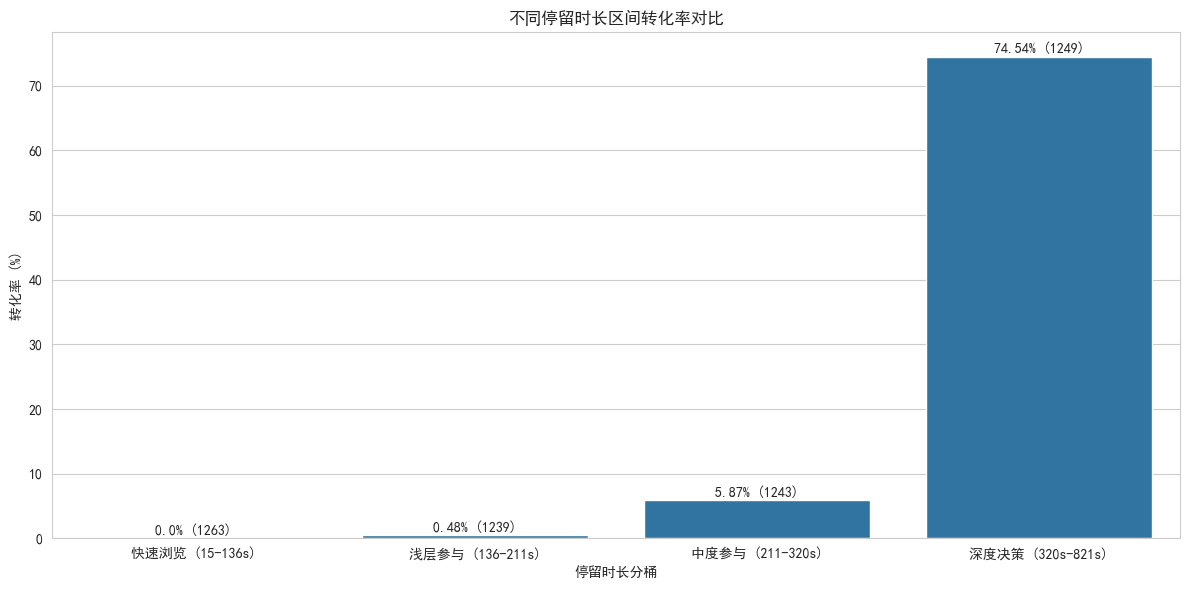

In [45]:
# 6. 可视化（带样本量标注）
plt.figure(figsize=(12, 6))
sns.barplot(data=duration_bucket, x='时长分桶', y='转化率')
plt.title('不同停留时长区间转化率对比')
plt.xlabel('停留时长分桶')
plt.ylabel('转化率 (%)')

# 在柱子上标注具体数值
for i, row in duration_bucket.iterrows():
    plt.text(i, row['转化率'] + 0.5, f'{row["转化率"]}% ({row["用户数"]})', ha='center')

plt.tight_layout()
plt.savefig('../visualization/duration_conversion_qcut.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.5 购物车商品数（ItemsInCart）与转化关系（加购流失分析）

C:\Users\30360\AppData\Local\Temp\ipykernel_22900\3529402496.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\30360\AppData\Local\Temp\ipykernel_22900\3529402496.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




购物车商品数量与转化率关系：
   购物车分桶   是否转化
0     0件   0.00
1   1-2件  36.15
2   3-5件  33.75
3  6-10件    NaN
4   10件+    NaN


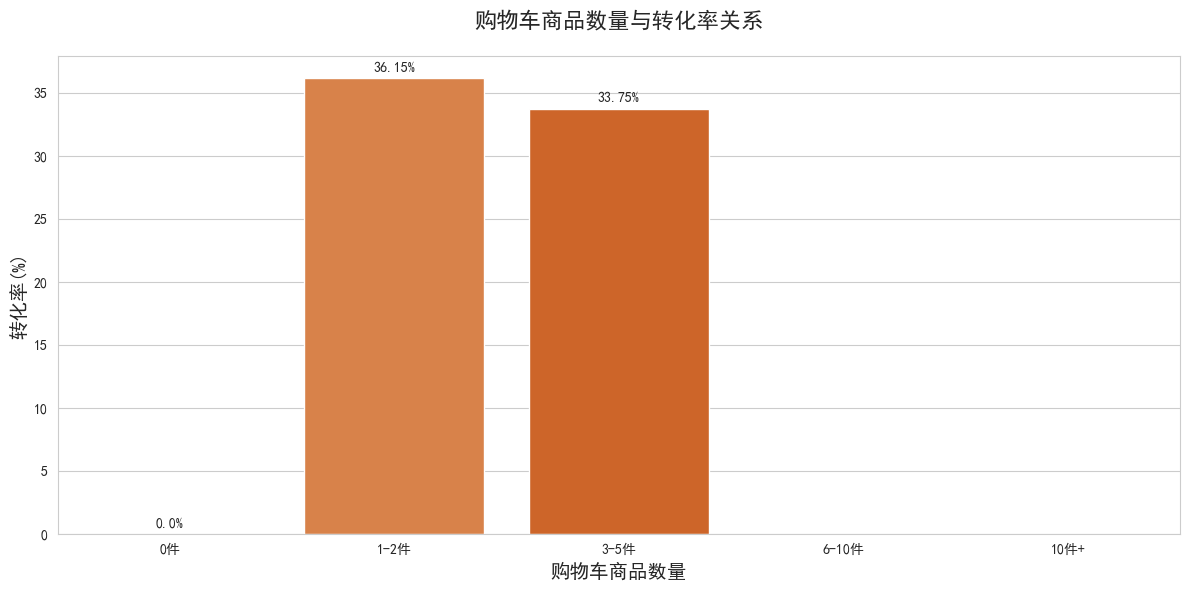

In [46]:
# 1. 按会话统计最大购物车商品数
cart_analysis = df.groupby('SessionID').agg(
    最大购物车商品数=('ItemsInCart', 'max'),
    是否转化=('session_is_converted', 'max')
)

# 2. 分桶分析
cart_analysis['购物车分桶'] = pd.cut(cart_analysis['最大购物车商品数'],
                                     bins=[-1, 0, 2, 5, 10, float('inf')],
                                     labels=['0件', '1-2件', '3-5件', '6-10件', '10件+'])
cart_bucket = cart_analysis.groupby('购物车分桶')['是否转化'].mean().reset_index()
cart_bucket['是否转化'] = round(cart_bucket['是否转化'] * 100, 2)

print("购物车商品数量与转化率关系：")
print(cart_bucket)

# 3. 可视化
plt.figure(figsize=(12, 6))
sns.barplot(x='购物车分桶', y='是否转化', data=cart_bucket, palette='Oranges_d')
plt.title('购物车商品数量与转化率关系', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('转化率(%)', fontsize=14)
plt.xlabel('购物车商品数量', fontsize=14)
for i, v in enumerate(cart_bucket['是否转化']):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualization/cart_items_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.6 用户行为路径分析（高阶分析，面试加分）

In [47]:
# 性能优化版：使用更高效的聚合方式
# 注意：原始的 groupby + apply + lambda 在大数据集上会很慢

# 方法1：基于funnel_wide表快速生成路径（推荐，性能更好）
# 从漏斗宽表反向生成路径，避免对全量数据做字符串拼接
def generate_path_from_funnel(row):
    """根据漏斗标记生成路径字符串"""
    path = []
    if row['step1_home'] == 1:
        path.append('1.访问首页')
    if row['step2_product'] == 1:
        path.append('2.浏览商品')
    if row['step3_cart'] == 1:
        path.append('3.加入购物车')
    if row['step4_checkout'] == 1:
        path.append('4.提交订单')
    if row['step5_confirm'] == 1:
        path.append('5.支付成功')
    return ' → '.join(path)

path_from_funnel = funnel_wide.apply(generate_path_from_funnel, axis=1)
top_paths_funnel = pd.Series(path_from_funnel).value_counts().head(10)

print("Top10用户行为路径（基于漏斗宽表）：")
print(top_paths_funnel)

Top10用户行为路径（基于漏斗宽表）：
1.访问首页 → 2.浏览商品                                2388
1.访问首页                                         1013
1.访问首页 → 2.浏览商品 → 3.加入购物车 → 4.提交订单 → 5.支付成功    1010
1.访问首页 → 2.浏览商品 → 3.加入购物车                       476
1.访问首页 → 2.浏览商品 → 3.加入购物车 → 4.提交订单              113
Name: count, dtype: int64



Top10用户行为路径（精确版）：
stage
1.访问首页 → 2.浏览商品                                2388
1.访问首页                                         1013
1.访问首页 → 2.浏览商品 → 3.加入购物车 → 4.提交订单 → 5.支付成功    1010
1.访问首页 → 2.浏览商品 → 3.加入购物车                       476
1.访问首页 → 2.浏览商品 → 3.加入购物车 → 4.提交订单              113
Name: count, dtype: int64


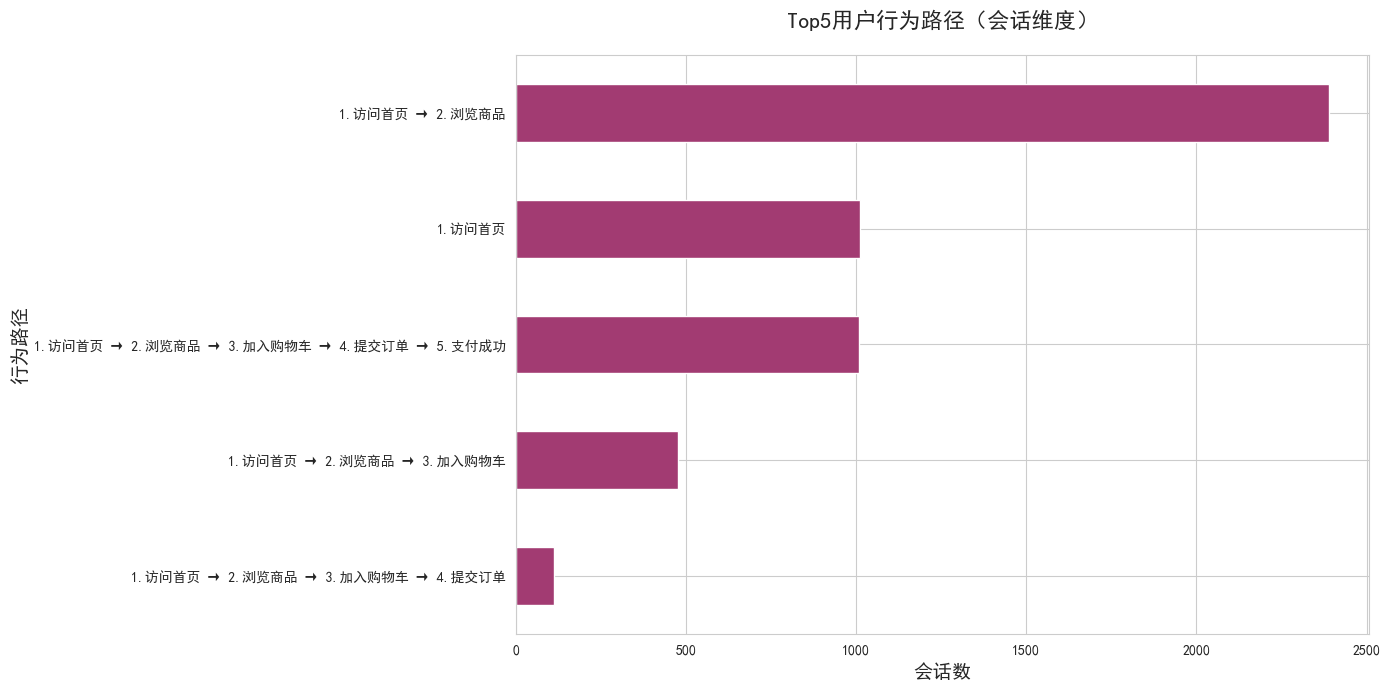

In [48]:
# 方法2：如果需要精确路径分析（用会话级别聚合，比apply快）
# 先按会话+stage排序，再去重，最后聚合
df_stages_sorted = df.sort_values(['SessionID', 'Timestamp'])[['SessionID', 'stage']].drop_duplicates()
path_strings = df_stages_sorted.groupby('SessionID')['stage'].agg(lambda x: ' → '.join(x))
top_paths_exact = path_strings.value_counts().head(10)

print("\nTop10用户行为路径（精确版）：")
print(top_paths_exact)

# 可视化Top5路径
plt.figure(figsize=(14, 7))
top_paths_exact.head(5).plot(kind='barh', color='#A23B72')
plt.title('Top5用户行为路径（会话维度）', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('会话数', fontsize=14)
plt.ylabel('行为路径', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../visualization/top_user_paths.png', dpi=300, bbox_inches='tight')
plt.show()